# Chapter 3 - Exercise 13
Simulated data: fit simple linear regression models to `y = -1 + 0.5x + eps`.

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS, summarize, poly

**(a)** Generate `x` from N(0, 1), n = 100.

In [ ]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)

**(b)** Generate `eps` from N(0, 0.25).

In [ ]:
eps = rng.normal(scale=np.sqrt(0.25), size=100)

**(c)** Generate `y = -1 + 0.5x + eps`.

In [ ]:
y = -1 + 0.5 * x + eps
len(y)

100

**(d)** Scatterplot of `x` vs. `y`.

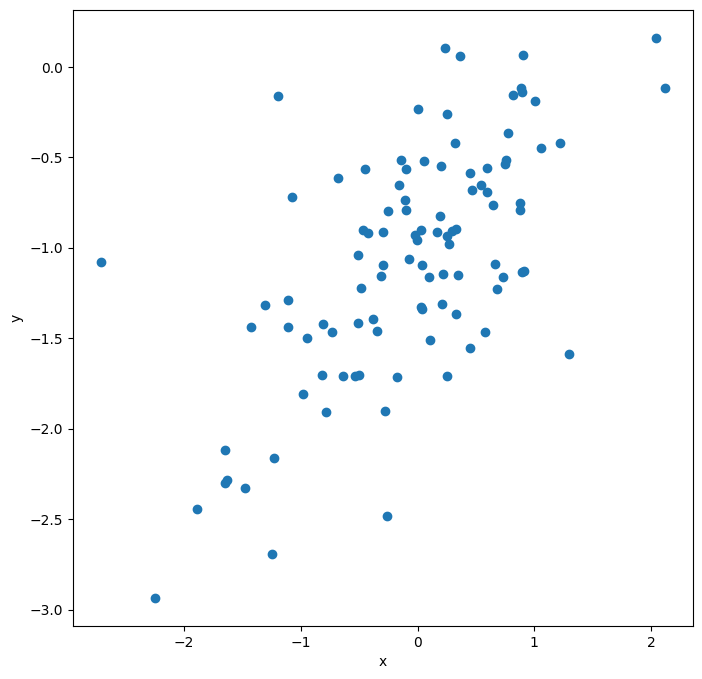

In [5]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(x, y)
ax.set_xlabel('x')
ax.set_ylabel('y');

**(e)** Fit a least squares model and compare estimated to true coefficients.

In [6]:
df = pd.DataFrame({'x': x, 'y': y})
design = MS(['x'])
X = design.fit_transform(df)
results = sm.OLS(df['y'], X).fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-1.0380,0.050,-20.647,0.0
x,0.4843,0.059,8.233,0.0


The estimated β̂₀ and β̂₁ are close to the true β0 = -1 and β1 = 0.5, as expected since least squares is unbiased and n = 100 is a reasonably large sample.

**(f)** Plot the least squares line and the true population line.

In [7]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

/tmp/ipykernel_700/877697705.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r-', linewidth=2, label='Least squares')


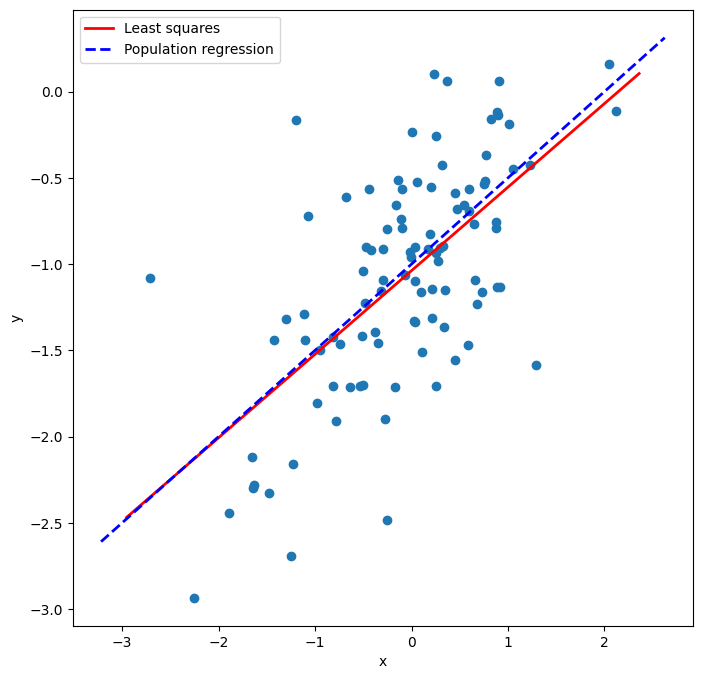

In [8]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(x, y)
abline(ax, results.params[0], results.params[1], 'r-', linewidth=2, label='Least squares')
abline(ax, -1, 0.5, 'b--', linewidth=2, label='Population regression')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend();

**(g)** Fit a quadratic model and compare to the linear fit.

In [ ]:
X_poly = MS([poly('x', degree=2, raw=True)]).fit_transform(df)
results_poly = sm.OLS(df['y'], X_poly).fit()
summarize(results_poly)

,coef,std err,t,P>|t|
intercept,-1.0364,0.060,-17.399,0.000
"poly(x, degree=2, raw=True)[0]",0.4831,0.063,7.647,0.000
"poly(x, degree=2, raw=True)[1]",-0.0024,0.045,-0.052,0.959


The quadratic term's p-value is above 0.05, so there is **no evidence** the quadratic term improves the fit.

**(h)** Repeat (a)-(f) with less noise (smaller error variance).

In [ ]:
rng = np.random.default_rng(1)
x_less = rng.normal(size=100)
eps_less = rng.normal(scale=np.sqrt(0.05), size=100)
y_less = -1 + 0.5 * x_less + eps_less
df_less = pd.DataFrame({'x': x_less, 'y': y_less})
X_less = design.fit_transform(df_less)
results_less = sm.OLS(df_less['y'], X_less).fit()
summarize(results_less)

,coef,std err,t,P>|t|
intercept,-1.017,0.022,-45.233,0.0
x,0.493,0.026,18.741,0.0


/tmp/ipykernel_700/1300799915.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results_less.params[0], results_less.params[1], 'r-', linewidth=2, label='Least squares')


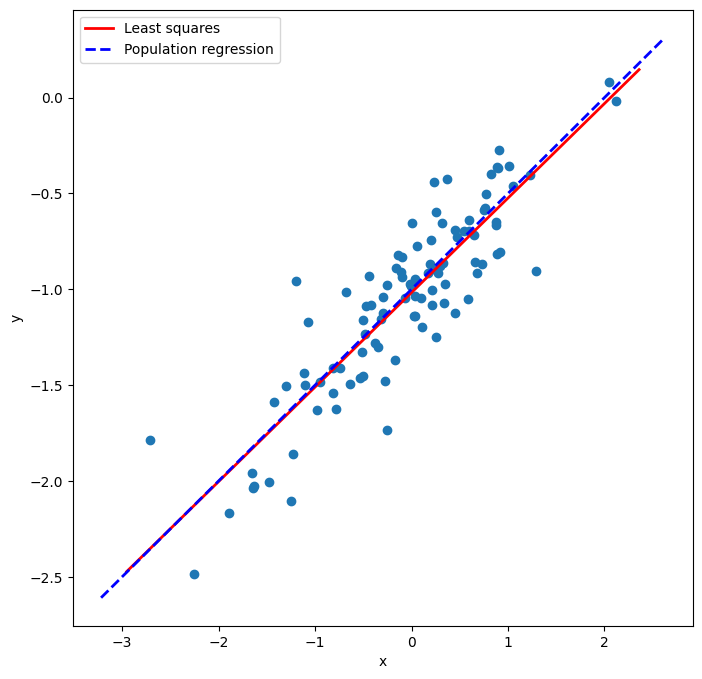

In [11]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(x_less, y_less)
abline(ax, results_less.params[0], results_less.params[1], 'r-', linewidth=2, label='Least squares')
abline(ax, -1, 0.5, 'b--', linewidth=2, label='Population regression')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend();

With less noise, the points hug the line more tightly, the R² is higher, and the estimated coefficients are even closer to the true β0 = -1, β1 = 0.5.

**(i)** Repeat (a)-(f) with more noise (larger error variance).

In [ ]:
rng = np.random.default_rng(1)
x_more = rng.normal(size=100)
eps_more = rng.normal(scale=np.sqrt(1.0), size=100)
y_more = -1 + 0.5 * x_more + eps_more
df_more = pd.DataFrame({'x': x_more, 'y': y_more})
X_more = design.fit_transform(df_more)
results_more = sm.OLS(df_more['y'], X_more).fit()
summarize(results_more)

,coef,std err,t,P>|t|
intercept,-1.0760,0.101,-10.701,0.0
x,0.4686,0.118,3.983,0.0


/tmp/ipykernel_700/1116302115.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results_more.params[0], results_more.params[1], 'r-', linewidth=2, label='Least squares')


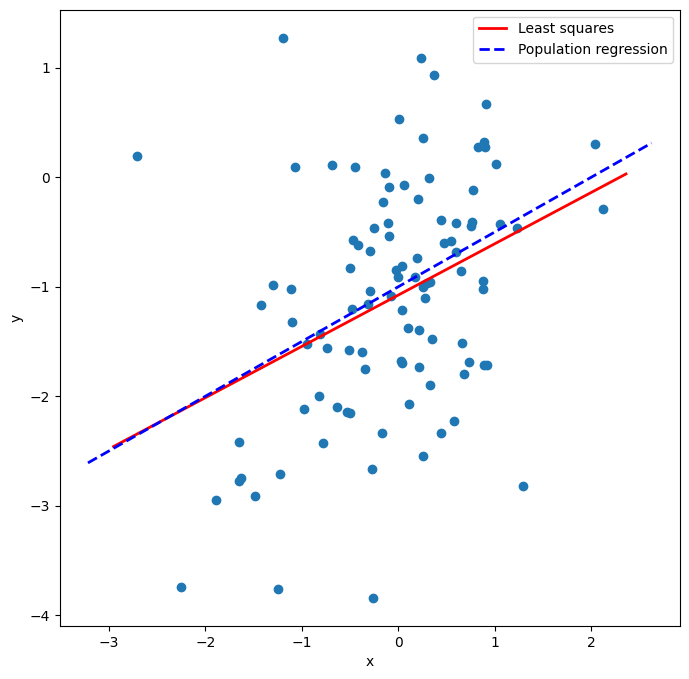

In [13]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(x_more, y_more)
abline(ax, results_more.params[0], results_more.params[1], 'r-', linewidth=2, label='Least squares')
abline(ax, -1, 0.5, 'b--', linewidth=2, label='Population regression')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend();

With more noise, the points scatter further from the line, R² drops, and the standard errors of β̂₀ and β̂₁ grow — the coefficient estimates become less precise, though still roughly unbiased.

**(j)** Compare confidence intervals for β0 and β1 across the three data sets.

In [14]:
pd.concat({
    'original': results.conf_int().rename(columns={0: 'lower', 1: 'upper'}),
    'less_noise': results_less.conf_int().rename(columns={0: 'lower', 1: 'upper'}),
    'more_noise': results_more.conf_int().rename(columns={0: 'lower', 1: 'upper'}),
})

lower     upper
original   intercept -1.137782 -0.938244
           x          0.367565  0.601017
less_noise intercept -1.061618 -0.972382
           x          0.440773  0.545176
more_noise intercept -1.275564 -0.876487
           x          0.235131  0.702033

All three intervals are centered near the true β0 = -1 and β1 = 0.5. The **less noisy** data gives the **narrowest** intervals, while the **noisier** data gives the **widest** intervals — more error variance means less certainty about the true coefficients.